# Kernel Token Contradiction: Figures 1 and 3

Notebook to reproduce the motivating example (Figures 1 and 3).

In [1]:
import os

os.chdir(os.path.dirname(os.path.abspath("")))

In [2]:
from src.annotation import get_annotation_from_idx, get_all_annotations
from src.signals.utils import get_wiki_adcacency_weights, get_model_embedding, get_embedding_similarity, get_wiki_adjacency
from src.generation import get_tokenizer, get_model
from src.signals.utils import heat_kernel
from src.signals import *
from src.signals.plot_utils import *
from src.utils import paths


import matplotlib.gridspec as gridspec
from matplotlib import pyplot as plt
from scipy.stats import entropy
import numpy as np
from tqdm import tqdm

In [3]:
all_annotations = get_all_annotations()
all_annotations = {key: value for key, value in all_annotations.items() if value.generation.lang == "en" and "$1,699" in value.generation.output and "IS STM lens" in value.generation.output}
annot_id = list(all_annotations)[np.random.randint(len(all_annotations))]
annotation = all_annotations[annot_id]
annotation

annotation = get_annotation_from_idx("uL0ofLzDJuLrcZqMACI2Xg")
annotation

Annotation[uL0ofLzDJuLrcZqMACI2Xg] What was the suggested retail price of the Canon EOS 70D when it was announced in 2013?
# 0 Labels=<gpt-4o: 1|gpt-4.1: 1> : The suggested retail price
# 1 Labels=<gpt-4o: 1|gpt-4.1: 1> :  of the Canon EOS 70D
# 2 Labels=<gpt-4o: 1|gpt-4.1: 1> :  when it was announced
# 3 Labels=<gpt-4o: 1|gpt-4.1: 1> :  in 2013
# 4 Labels=<gpt-4o: 1|gpt-4.1: 1> :  was $1,199
# 5 Labels=<gpt-4o: 1|gpt-4.1: 1> :  for the body
# 6 Labels=<gpt-4o:-1|gpt-4.1:-1> :  only, and $1,699
# 7 Labels=<gpt-4o: 1|gpt-4.1: 1> :  with an EF-S 18-55mm
# 8 Labels=<gpt-4o: 1|gpt-4.1: 1> :  IS STM lens.
# 9 Labels=<gpt-4o: 1|gpt-4.1: 1> : <|eot_id|>

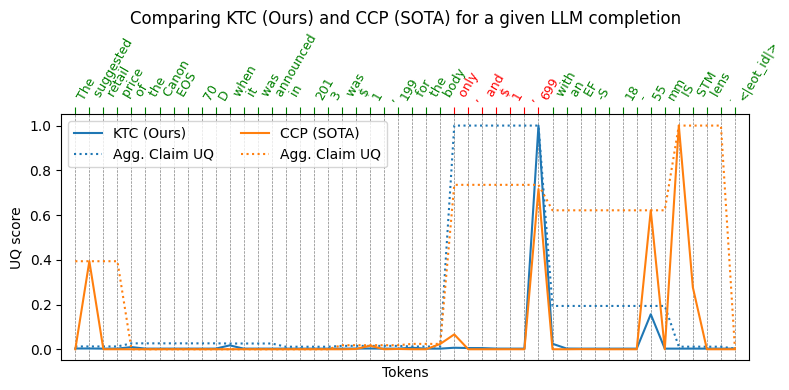

In [4]:
sig_ktc = SignalKTC(ktc_config_id=KTCConfig(nu=4, tau=0.7).id)
ktc_value = sig_ktc.search_generation(annotation).renorm()

sig_ccp = SignalCCP(delta=24, sigma=8, size="L")
ccp_value = sig_ccp.search_generation(annotation).renorm()

sig_likelihood = SignalTokenLikelihood()
likelihood_value = sig_likelihood.search_generation(annotation).renorm()

fig = get_plot(annotation, [ktc_value, ccp_value], pretty_names=["KTC (Ours)", "CCP (SOTA)"], title_char_len=120)
fig.axes[0].set_title("Comparing KTC (Ours) and CCP (SOTA) for a given LLM completion")
fig.tight_layout()
fig.savefig(paths.root / "figures" / "teaser_ktc_curve.pdf")

In [5]:
sig_ktc.ktc_config

KTCConfig[ Y5SPgJbW-B1aiI18hewM8w ](
	_base_output_dir: .
	alpha: 0.5
	delta: 24
	kernel_method: heat
	language_specific: False
	normalization_method: scale
	nu: 4
	prefix_entail: True
	sigma: 3
	tau: 0.7
	token_position: 0
)

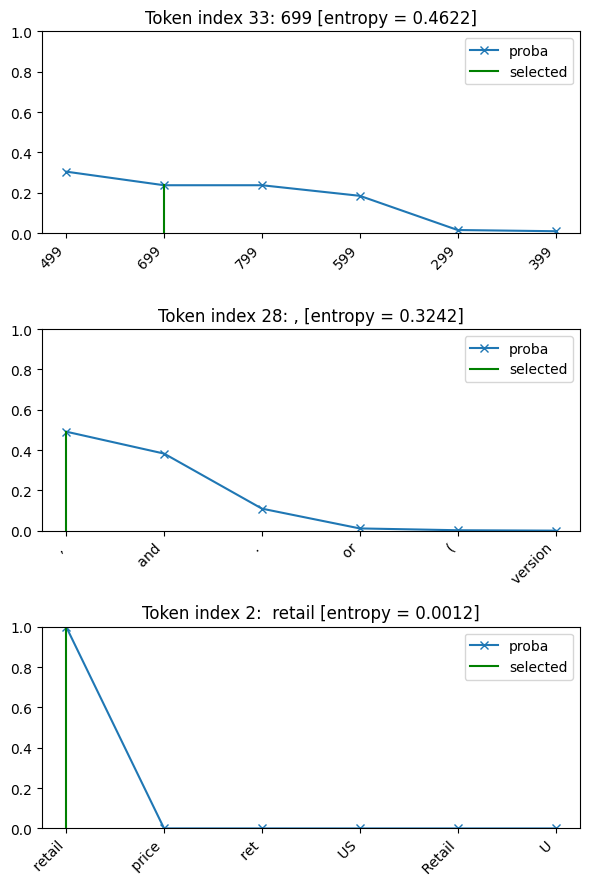

In [6]:
get_plot_debug_token_proba(annotation, only_indices=[33, 28, 2], delta=6);
# get_plot_debug_token_proba(annotation);

In [7]:
INDICES = [33, 28, 2]
TITLES = ["Epistemic", "Aleatoric", "Low entropy"]
DELTA=5

model_name = annotation.generation.generation_cfg.model_name
tokenizer = get_tokenizer(model_name)

In [8]:
idx_token, current_title = INDICES[2], TITLES[2]

topn_prob_dicts = annotation.generation.topn_prob_dicts[idx_token]
sorted_probs = sorted(
    annotation.generation.topn_prob_dicts[idx_token].values(), reverse=True
)[:DELTA]
sorted_token_indices = sorted(
    annotation.generation.topn_prob_dicts[idx_token],
    key=annotation.generation.topn_prob_dicts[idx_token].get,
    reverse=True,
)[:DELTA]
decoded_tokens = [
    tokenizer.decode(sorted_token_indices[rank])
    for rank in range(DELTA)
]
local_entropy = entropy(sorted_probs) / np.log(24)

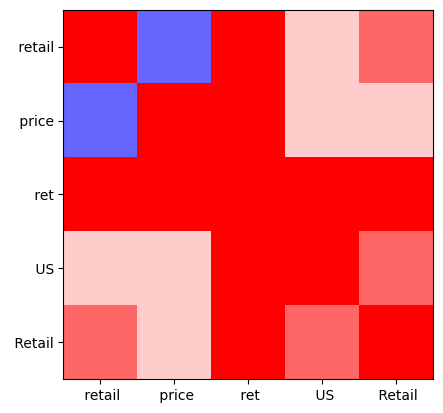

In [9]:
wiki_adjacency = get_wiki_adjacency(sorted_token_indices, nu=5, model_name=model_name, prefix_entail=True)

fig, ax = plt.subplots()
ax.imshow(wiki_adjacency, cmap="bwr", vmin=0, vmax=1)
ax.set_xticks(list(range(DELTA)))
ax.set_yticks(list(range(DELTA)))
ax.set_xticklabels(decoded_tokens)
ax.set_yticklabels(decoded_tokens)

fig;

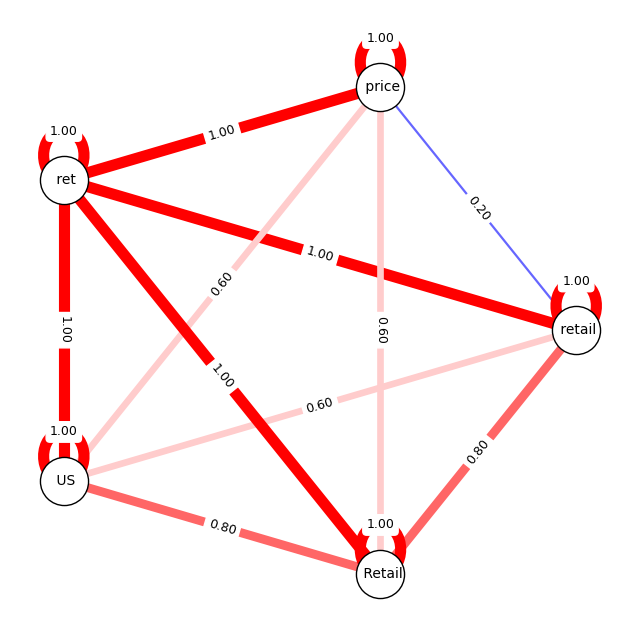

In [10]:
import networkx as nx
import matplotlib as mpl

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
graph = nx.from_numpy_array(wiki_adjacency.numpy())
pos = nx.circular_layout(graph)

# Edge weights
weights = nx.get_edge_attributes(graph, "weight")
widths = [8*w for w in weights.values()]

norm = mpl.colors.Normalize(vmin=0, vmax=1)
cmap = plt.cm.bwr
edge_colors = [cmap(norm(w)) for w in weights.values()]

# Node labels
node_labels = {i: tok for i, tok in enumerate(decoded_tokens)}

nx.draw(
    graph,
    pos,
    ax=ax,
    with_labels=True,
    labels=node_labels,
    width=widths,
    node_color="white",
    edgecolors="black",
    edge_color=edge_colors,
    node_size=1200,
    font_size=10
)

# Edge labels (2-digit precision)
edge_labels = {e: f"{w:.2f}" for e, w in weights.items()}
nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_size=9)

plt.show()

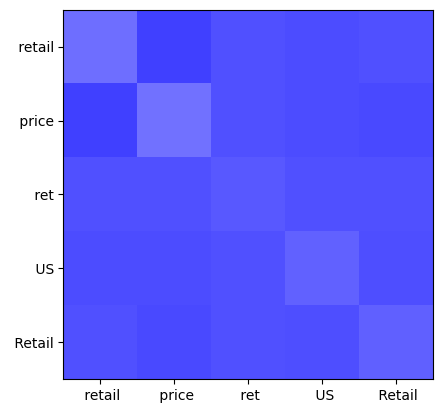

In [11]:
graph_kernel = heat_kernel(wiki_adjacency, tau=0.8)
fig, ax = plt.subplots()
ax.imshow(graph_kernel, cmap="bwr", vmin=0, vmax=1)
ax.set_xticks(list(range(DELTA)))
ax.set_yticks(list(range(DELTA)))
ax.set_xticklabels(decoded_tokens)
ax.set_yticklabels(decoded_tokens)

fig;

/var/folders/sm/rc925df91t51vmr_0m6wpdj80000gn/T/ipykernel_47322/3274834789.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  eigenvectors_normalized = eigenvectors / np.linalg.norm(eigenvectors, axis=0)


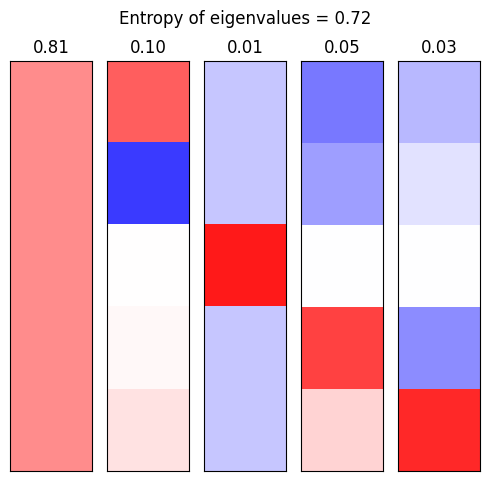

In [12]:
# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(graph_kernel)
eigenvectors_normalized = eigenvectors / np.linalg.norm(eigenvectors, axis=0)
eigenvalue_entropy = -np.sum(eigenvalues * np.log(eigenvalues))

# Plot eigenvectors as bars of height 5, with each cell corresponding to the coordinate
plt.figure(figsize=(5, 5))

# Plot each eigenvector
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(eigenvectors_normalized[:, i].reshape(-1, 1), cmap='bwr', vmin=-1, vmax=1)
    plt.xticks([])
    plt.yticks([])
    plt.title(f'{eigenvalues[i]:.2f}')

plt.suptitle(f'Entropy of eigenvalues = {eigenvalue_entropy:.2f}')
plt.tight_layout()
plt.show()

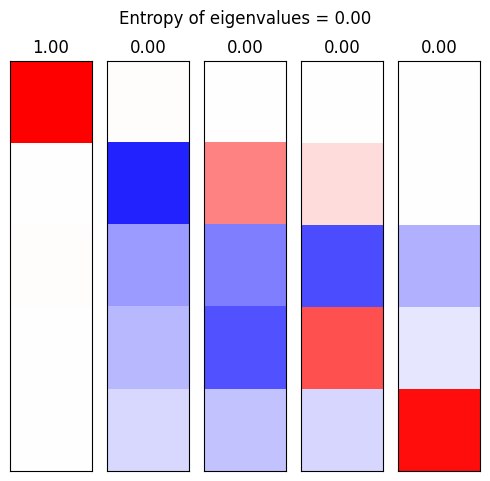

In [13]:
pi = np.diag(sorted_probs)
# normalized_kernel = graph_kernel.numpy() @ pi
normalized_kernel = (pi ** (1/2)) @ graph_kernel.numpy() @ (pi ** (1/2) )
normalized_kernel /= normalized_kernel.trace()

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(normalized_kernel)
eigenvectors_normalized = eigenvectors / np.linalg.norm(eigenvectors, axis=0)
eigenvalue_entropy = -np.sum(eigenvalues * np.log(eigenvalues))

# Plot eigenvectors as bars of height 5, with each cell corresponding to the coordinate
plt.figure(figsize=(5, 5))

# Plot each eigenvector
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(eigenvectors_normalized[:, i].reshape(-1, 1), cmap='bwr', vmin=-1, vmax=1)
    plt.xticks([])
    plt.yticks([])
    plt.title(f'{eigenvalues[i]:.2f}')

plt.suptitle(f'Entropy of eigenvalues = {eigenvalue_entropy:.2f}')
plt.tight_layout()
plt.show()

## Combined figure

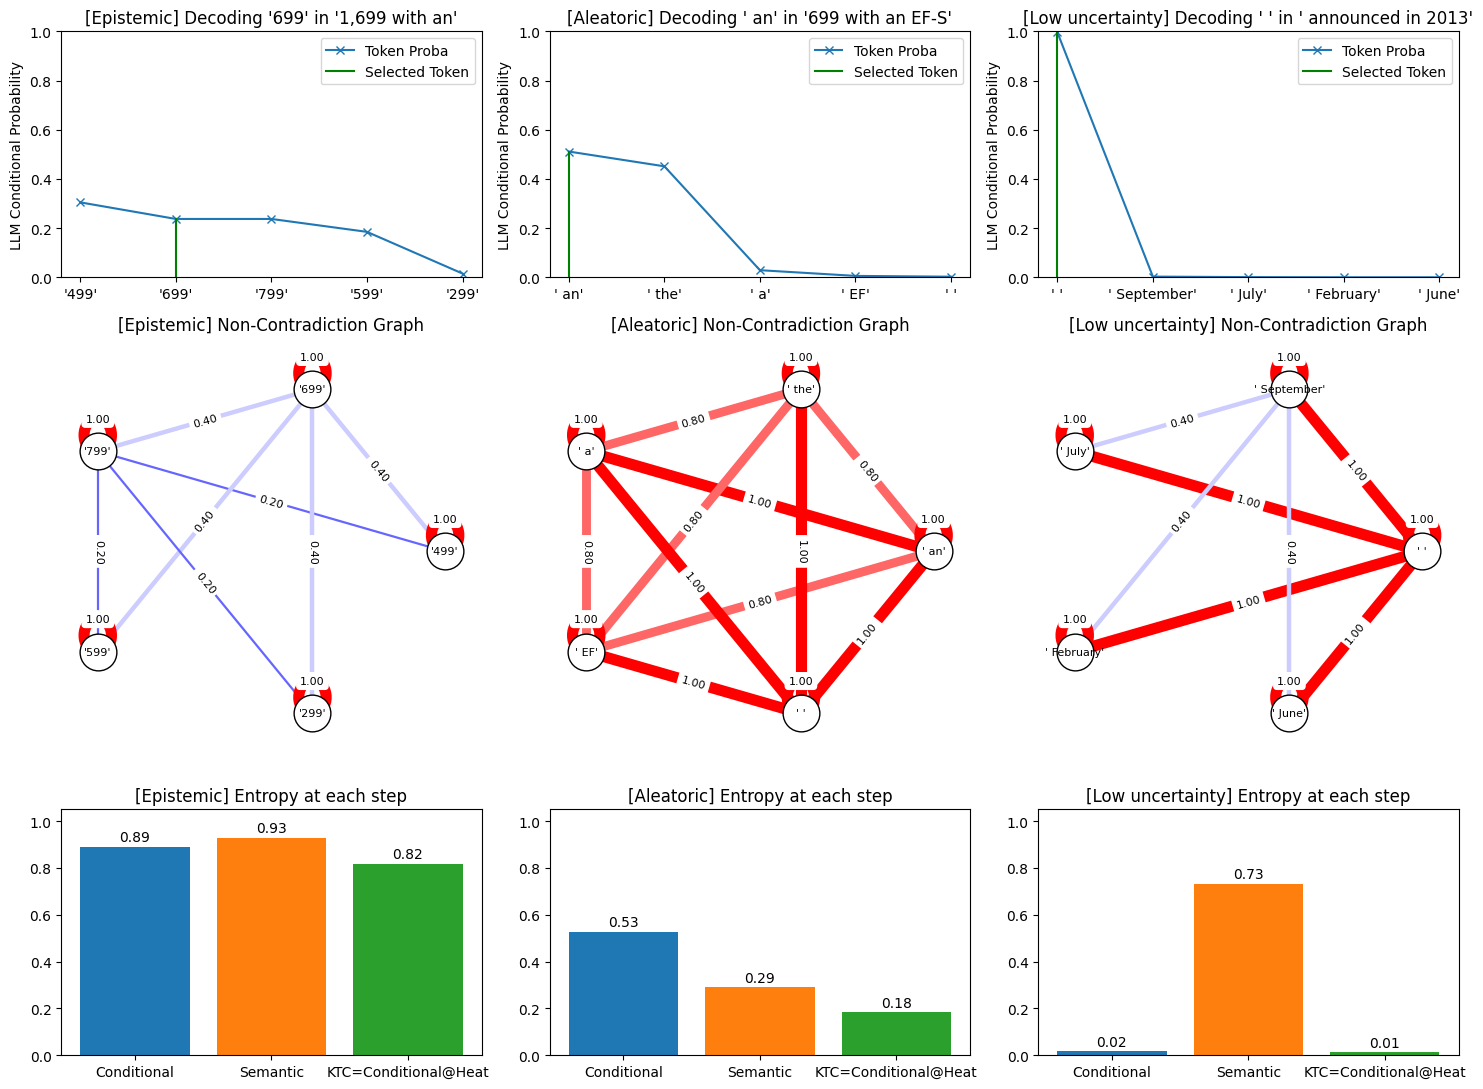

In [14]:
INDICES = [33, 35, 16]
TITLES = ["Epistemic", "Aleatoric", "Low uncertainty"]
DELTA=5

model_name = annotation.generation.generation_cfg.model_name
tokenizer = get_tokenizer(model_name)

fig, axes = plt.subplots(3, 3, figsize=(15, 11), gridspec_kw={'height_ratios': [3, 5, 3]})

# Iterating over samples
for col in range(3):
    # Unpacking
    idx_token, current_title = INDICES[col], TITLES[col]
    selected_token = tokenizer.decode(annotation.generation.output_tokens[idx_token])
    topn_prob_dicts = annotation.generation.topn_prob_dicts[idx_token]
    sorted_probs = sorted(
        annotation.generation.topn_prob_dicts[idx_token].values(), reverse=True
    )[:DELTA]
    sorted_token_indices = sorted(
        annotation.generation.topn_prob_dicts[idx_token],
        key=annotation.generation.topn_prob_dicts[idx_token].get,
        reverse=True,
    )[:DELTA]
    decoded_tokens = [
        tokenizer.decode(sorted_token_indices[rank])
        for rank in range(DELTA)
    ]
    rank_of_sampled = decoded_tokens.index(selected_token)
    decoded_tokens = [f"'{item}'" for item in decoded_tokens]
    local_entropy = entropy(sorted_probs) / np.log(DELTA)

    # Textual context
    context_before = tokenizer.decode(annotation.generation.output_tokens[idx_token - 2:idx_token])
    context_self = tokenizer.decode(annotation.generation.output_tokens[idx_token])
    context_after = tokenizer.decode(annotation.generation.output_tokens[idx_token+1:idx_token+3])

    # First plot - decoding
    axes[0, col].set_title(f"[{current_title}] Decoding '{context_self}' in '{context_before}{context_self}{context_after}'")
    axes[0, col].plot(range(DELTA), sorted_probs, marker="x", label="Token Proba")
    axes[0, col].axvline(rank_of_sampled, ymin=0, ymax=sorted_probs[rank_of_sampled], color="green", label="Selected Token")
    axes[0, col].set_ylim(0, 1)
    axes[0, col].set_xticks(range(DELTA))
    axes[0, col].set_xticklabels(decoded_tokens, ha="center")
    axes[0, col].set_ylabel("LLM Conditional Probability")
    axes[0, col].legend()
    axes[0, col].margins(y=5)

    # Second plot - graph
    wiki_adjacency = get_wiki_adjacency(sorted_token_indices, nu=5, model_name=model_name, prefix_entail=True)
    graph = nx.from_numpy_array(wiki_adjacency.numpy())
    pos = nx.circular_layout(graph)

    weights = nx.get_edge_attributes(graph, "weight")
    widths = [8*w for w in weights.values()]

    norm = mpl.colors.Normalize(vmin=0, vmax=1)
    cmap = plt.cm.bwr
    edge_colors = [cmap(norm(w)) for w in weights.values()]

    node_labels = {i: tok for i, tok in enumerate(decoded_tokens)}
    nx.draw(graph, pos, ax=axes[1, col], with_labels=True, labels=node_labels, width=widths, node_color="white", edgecolors="black", edge_color=edge_colors, node_size=700, font_size=8)

    edge_labels = {e: f"{w:.2f}" for e, w in weights.items()}
    nx.draw_networkx_edge_labels(graph, pos, ax=axes[1, col], edge_labels=edge_labels, font_size=8)

    axes[1, col].set_title(f"[{current_title}] Non-Contradiction Graph")

    # Third graph - graph kernel entropy
    graph_kernel = heat_kernel(wiki_adjacency, tau=0.8)
    eigenvalues, eigenvectors = np.linalg.eig(graph_kernel)
    eigenvalues /= eigenvalues.sum()
    eigenvalues_entropy_heat = entropy(eigenvalues) / np.log(DELTA)
    # axes[2, col].bar([k - 0.2 for k in range(DELTA)], sorted(eigenvalues, reverse=True), width=0.3, label=f"[Entropy={eigenvalues_entropy_heat:.2f}] Heat Kernel")
    
    pi = torch.Tensor(np.diag(sorted_probs))
    eigenvalues, eigenvectors = np.linalg.eig((graph_kernel @ pi).numpy())
    eigenvalues /= eigenvalues.sum()
    eigenvalues_entropy_norm = entropy(eigenvalues) / np.log(DELTA)
    # axes[2, col].bar([k + 0.2 for k in range(DELTA)], sorted(eigenvalues, reverse=True), width=0.3, label=f"[Entropy={eigenvalues_entropy_norm:.2f}] Heat Kernel + Conditional")

    # axes[2, col].set_ylim(0, 1.05)
    # axes[2, col].set_xticks(list(range(DELTA)))
    # axes[2, col].set_xticklabels([f"Eig {k}" for k in range(DELTA)])
    # axes[2, col].legend()
    # axes[2, col].set_title(f"[{current_title}] Entropy of Eigenvalues")

    bar = axes[2, col].bar([0], [local_entropy])
    axes[2, col].bar_label(bar, fmt='%.2f', padding=2, fontsize=10)
    bar = axes[2, col].bar([1], [eigenvalues_entropy_heat])
    axes[2, col].bar_label(bar, fmt='%.2f', padding=2, fontsize=10)
    bar = axes[2, col].bar([2], [eigenvalues_entropy_norm])
    axes[2, col].bar_label(bar, fmt='%.2f', padding=2, fontsize=10)
    axes[2, col].set_xticks([0, 1, 2])
    axes[2, col].set_xticklabels(["Conditional", "Semantic", "KTC=Conditional@Heat"])
    axes[2, col].set_title(f"[{current_title}] Entropy at each step")
    axes[2, col].set_ylim(0, 1.05)

fig.tight_layout()
fig.savefig(paths.root / "figures" / "explaining_ktc.pdf")